# Emergency Department Triage Acuity: EDA and Preprocessing Handoff

This notebook is limited to exploratory data analysis (EDA), data integrity checks, leakage review, and reusable preprocessing for the modeling team.

It does **not** train models, tune classifiers, create validation predictions, or generate Kaggle submissions.

## Project setup

Key modeling constraints for the handoff:

- `triage_acuity` is the target label and must not be used as a feature.
- `disposition` and `ed_los_hours` are post-triage outcomes. They are leakage because they are only known after triage decisions are made, so they must be removed from modeling features.
- `patient_id` is only for merging related files and preserving row alignment for downstream outputs. It must not be used as a model feature.
- `chief_complaint_raw` contains repeated templates and can create shortcut learning. Future text models should compare random validation with `GroupKFold` grouped by `chief_complaint_raw_clean`.
- This notebook prepares clean train/test feature files only. Modeling will be done separately.

In [26]:
from pathlib import Path

import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:  # Fallback for running as a plain Python script.
    display = print

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
COMPLAINTS_PATH = DATA_DIR / "chief_complaints.csv"
HISTORY_PATH = DATA_DIR / "patient_history.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

TARGET_COL = "triage_acuity"
ID_COL = "patient_id"
LEAKAGE_COLS = ["disposition", "ed_los_hours"]

KEY_CLINICAL_COLS = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score",
    "news2_score",
]

CORE_VITAL_COLS = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
]

CATEGORICAL_DRIFT_COLS = [
    "site_id",
    "triage_nurse_id",
    "arrival_mode",
    "language",
    "insurance_type",
    "transport_origin",
    "pain_location",
    "mental_status_triage",
    "chief_complaint_system",
]

NUMERIC_DRIFT_COLS = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score_clean",
    "news2_score",
]

## Load raw data

In [27]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
chief_complaints = pd.read_csv(COMPLAINTS_PATH)
patient_history = pd.read_csv(HISTORY_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

raw_shapes = pd.DataFrame(
    {
        "dataset": ["train", "test", "chief_complaints", "patient_history", "sample_submission"],
        "rows": [len(train), len(test), len(chief_complaints), len(patient_history), len(sample_submission)],
        "columns": [train.shape[1], test.shape[1], chief_complaints.shape[1], patient_history.shape[1], sample_submission.shape[1]],
    }
)
display(raw_shapes)

,dataset,rows,columns
0,train,80000,40
1,test,20000,37
2,chief_complaints,100000,3
3,patient_history,100000,26
4,sample_submission,20000,2


## Data integrity checks

In [28]:
def summarize_id_integrity(datasets, id_col=ID_COL):
    rows = []
    for name, df in datasets.items():
        rows.append(
            {
                "dataset": name,
                "rows": len(df),
                "unique_patient_id": df[id_col].nunique() if id_col in df.columns else np.nan,
                "duplicate_patient_id": int(df[id_col].duplicated().sum()) if id_col in df.columns else np.nan,
                "missing_patient_id": int(df[id_col].isna().sum()) if id_col in df.columns else np.nan,
            }
        )
    return pd.DataFrame(rows)

id_integrity = summarize_id_integrity(
    {
        "train": train,
        "test": test,
        "chief_complaints": chief_complaints,
        "patient_history": patient_history,
        "sample_submission": sample_submission,
    }
)
display(id_integrity)

train_ids = set(train[ID_COL])
test_ids = set(test[ID_COL])
complaint_ids = set(chief_complaints[ID_COL])
history_ids = set(patient_history[ID_COL])

merge_coverage = pd.DataFrame(
    [
        {"dataset": "train", "missing_complaint_rows": len(train_ids - complaint_ids), "missing_history_rows": len(train_ids - history_ids)},
        {"dataset": "test", "missing_complaint_rows": len(test_ids - complaint_ids), "missing_history_rows": len(test_ids - history_ids)},
    ]
)
display(merge_coverage)

column_comparison = pd.DataFrame(
    {
        "train_only_columns": pd.Series(sorted(set(train.columns) - set(test.columns))),
        "test_only_columns": pd.Series(sorted(set(test.columns) - set(train.columns))),
    }
)
display(column_comparison)

,dataset,rows,unique_patient_id,duplicate_patient_id,missing_patient_id
0,train,80000,80000,0,0
1,test,20000,20000,0,0
2,chief_complaints,100000,100000,0,0
3,patient_history,100000,100000,0,0
4,sample_submission,20000,20000,0,0


,dataset,missing_complaint_rows,missing_history_rows
0,train,0,0
1,test,0,0


,train_only_columns,test_only_columns
0,disposition,NaN
1,ed_los_hours,NaN
2,triage_acuity,NaN


In [29]:
availability_table = pd.DataFrame(
    [
        {"column": ID_COL, "role": "merge/alignment only", "in_train": ID_COL in train.columns, "in_test": ID_COL in test.columns},
        {"column": TARGET_COL, "role": "target", "in_train": TARGET_COL in train.columns, "in_test": TARGET_COL in test.columns},
        *[
            {"column": col, "role": "post-triage leakage", "in_train": col in train.columns, "in_test": col in test.columns}
            for col in LEAKAGE_COLS
        ],
    ]
)
display(availability_table)

,column,role,in_train,in_test
0,patient_id,merge/alignment only,True,True
1,triage_acuity,target,True,False
2,disposition,post-triage leakage,True,False
3,ed_los_hours,post-triage leakage,True,False


In [30]:
# EDA-only merged training view. Preprocessing functions below perform the official transformations.
train_eda = train.merge(chief_complaints, on=ID_COL, how="left", suffixes=("", "_complaints"))
if "chief_complaint_system_complaints" in train_eda.columns:
    train_eda["chief_complaint_system"] = train_eda["chief_complaint_system"].combine_first(
        train_eda["chief_complaint_system_complaints"]
    )
    train_eda = train_eda.drop(columns=["chief_complaint_system_complaints"])
train_eda = train_eda.merge(patient_history, on=ID_COL, how="left")

print(f"EDA merged train shape: {train_eda.shape}")

EDA merged train shape: (80000, 66)


## EDA: target distribution

,triage_acuity,count,percent
0,1,3222,4.027
1,2,13439,16.799
2,3,28921,36.151
3,4,23020,28.775
4,5,11398,14.247


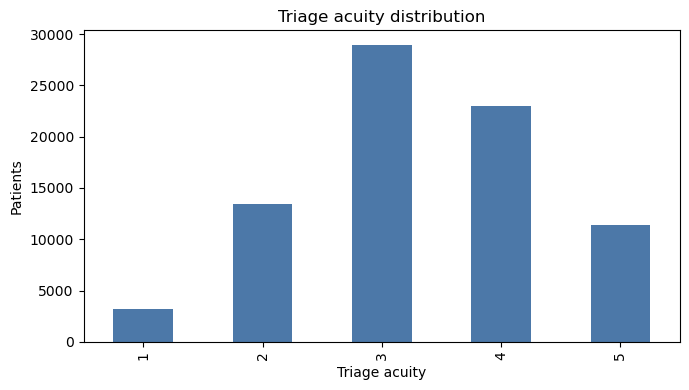

In [31]:
target_distribution = (
    train[TARGET_COL]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(TARGET_COL)
    .reset_index(name="count")
)
target_distribution["percent"] = target_distribution["count"] / len(train) * 100
display(target_distribution)

ax = target_distribution.plot.bar(x=TARGET_COL, y="count", legend=False, figsize=(7, 4), color="#4C78A8")
ax.set_title("Triage acuity distribution")
ax.set_xlabel("Triage acuity")
ax.set_ylabel("Patients")
plt.tight_layout()
plt.show()

In [32]:
high_acuity_summary = pd.DataFrame(
    {
        "group": ["ESI 1-2", "ESI 3", "ESI 4-5"],
        "count": [
            int(train[TARGET_COL].isin([1, 2]).sum()),
            int((train[TARGET_COL] == 3).sum()),
            int(train[TARGET_COL].isin([4, 5]).sum()),
        ],
    }
)
high_acuity_summary["percent"] = high_acuity_summary["count"] / len(train) * 100
display(high_acuity_summary)

,group,count,percent
0,ESI 1-2,16661,20.826
1,ESI 3,28921,36.151
2,ESI 4-5,34418,43.023


## EDA: missingness and invalid values

In [33]:
missing_summary = (
    train_eda.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_rate"})
)
missing_summary["missing_count"] = train_eda[missing_summary["column"]].isna().sum().to_numpy()
display(missing_summary.query("missing_count > 0").head(30))

clinical_missing_by_acuity = (
    train_eda.groupby(TARGET_COL)[[col for col in KEY_CLINICAL_COLS if col in train_eda.columns]]
    .apply(lambda x: x.isna().mean())
    .reset_index()
)
display(clinical_missing_by_acuity)

,column,missing_rate,missing_count
0,shock_index,0.052,4146
1,pulse_pressure,0.052,4146
2,systolic_bp,0.052,4146
3,diastolic_bp,0.052,4146
4,mean_arterial_pressure,0.052,4146
5,respiratory_rate,0.038,3067
6,temperature_c,0.007,574


,triage_acuity,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,news2_score
0,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,4,0.121,0.121,0.000,0.089,0.000,0.000,0.000,0.000,0.000
4,5,0.118,0.118,0.000,0.089,0.050,0.000,0.000,0.000,0.000


In [34]:
invalid_rules = {
    "pain_score": lambda s: (s < 0) | (s > 10),
    "gcs_total": lambda s: (s < 3) | (s > 15),
    "spo2": lambda s: (s < 0) | (s > 100),
    "temperature_c": lambda s: (s < 30) | (s > 45),
    "heart_rate": lambda s: (s < 20) | (s > 250),
    "respiratory_rate": lambda s: (s < 3) | (s > 80),
    "systolic_bp": lambda s: (s < 40) | (s > 300),
    "diastolic_bp": lambda s: (s < 20) | (s > 200),
}

invalid_summary = []
for col, rule in invalid_rules.items():
    if col in train_eda.columns:
        invalid_summary.append({"column": col, "invalid_count": int(rule(train_eda[col]).sum())})

if {"systolic_bp", "diastolic_bp"}.issubset(train_eda.columns):
    invalid_summary.append(
        {
            "column": "systolic_bp_lt_diastolic_bp",
            "invalid_count": int((train_eda["systolic_bp"] < train_eda["diastolic_bp"]).sum()),
        }
    )

display(pd.DataFrame(invalid_summary))

pain_score_clean_eda = train_eda["pain_score"].where(train_eda["pain_score"].between(0, 10))
missing_vital_count_eda = train_eda[[col for col in CORE_VITAL_COLS if col in train_eda.columns]].isna().sum(axis=1)

display(
    pd.DataFrame(
        {
            "pain_score_clean_missing_rate": [pain_score_clean_eda.isna().mean()],
            "mean_missing_vital_count": [missing_vital_count_eda.mean()],
            "max_missing_vital_count": [missing_vital_count_eda.max()],
        }
    )
)

,column,invalid_count
0,pain_score,11156
1,gcs_total,0
2,spo2,0
3,temperature_c,0
4,heart_rate,0
5,respiratory_rate,0
6,systolic_bp,0
7,diastolic_bp,0
8,systolic_bp_lt_diastolic_bp,2087


,pain_score_clean_missing_rate,mean_missing_vital_count,max_missing_vital_count
0,0.139,0.149,4


## EDA: clinical numerical variables

In [35]:
clinical_numeric_cols = [
    col
    for col in [
        "age",
        "systolic_bp",
        "diastolic_bp",
        "mean_arterial_pressure",
        "pulse_pressure",
        "heart_rate",
        "respiratory_rate",
        "temperature_c",
        "spo2",
        "gcs_total",
        "pain_score",
        "news2_score",
        "shock_index",
    ]
    if col in train_eda.columns
]

clinical_summary_by_acuity = train_eda.groupby(TARGET_COL)[clinical_numeric_cols].median().T
display(clinical_summary_by_acuity)

triage_acuity,1,2,3,4,5
age,49.000,48.000,48.000,48.000,48.000
systolic_bp,82.600,100.400,126.000,132.000,128.100
diastolic_bp,52.150,63.300,76.900,80.000,78.800
mean_arterial_pressure,62.100,75.500,93.300,97.300,95.300
pulse_pressure,30.300,37.300,49.300,52.100,49.000
heart_rate,119.200,108.700,93.000,84.100,76.800
respiratory_rate,28.000,23.000,18.000,16.000,15.000
temperature_c,38.900,38.500,37.700,37.200,36.900
spo2,85.900,92.000,96.000,98.000,99.000
gcs_total,6.500,12.000,15.000,15.000,15.000


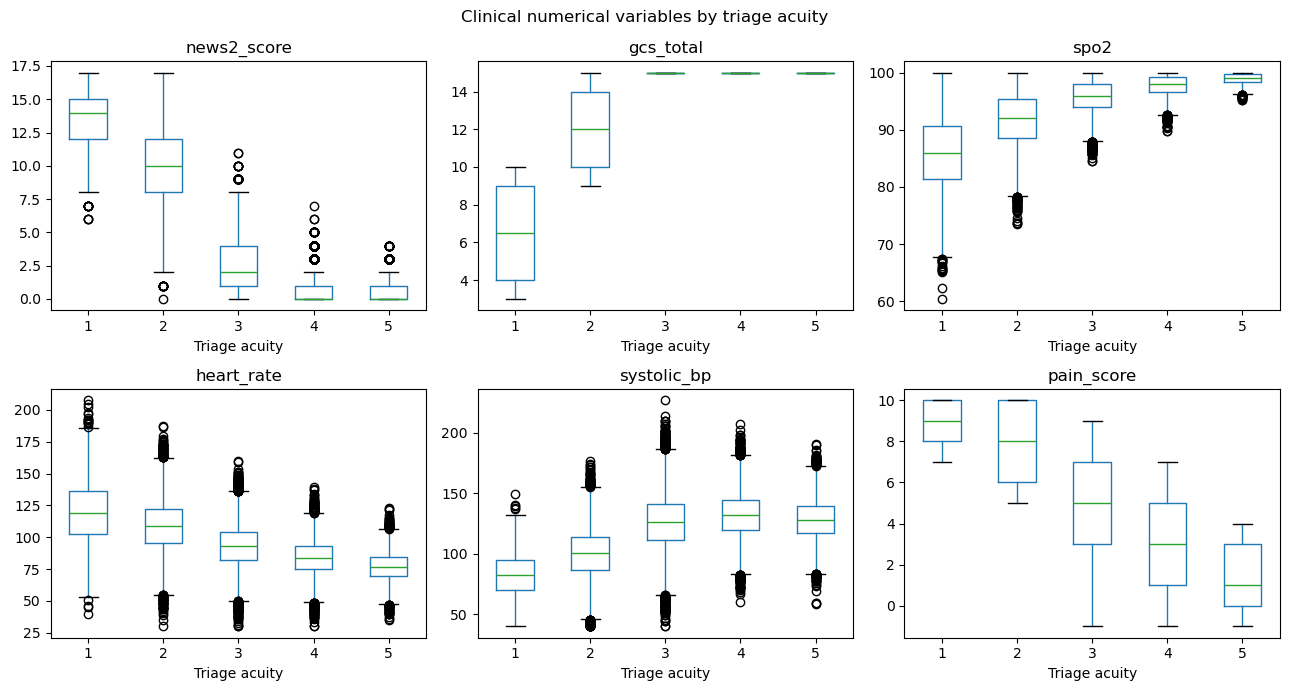

In [36]:
plot_cols = [col for col in ["news2_score", "gcs_total", "spo2", "heart_rate", "systolic_bp", "pain_score"] if col in train_eda.columns]
if plot_cols:
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(13, 7))
    axes = axes.ravel()
    for ax, col in zip(axes, plot_cols):
        train_eda.boxplot(column=col, by=TARGET_COL, ax=ax, grid=False)
        ax.set_title(col)
        ax.set_xlabel("Triage acuity")
    for ax in axes[len(plot_cols):]:
        ax.axis("off")
    fig.suptitle("Clinical numerical variables by triage acuity")
    plt.tight_layout()
    plt.show()

In [37]:
clinical_flag_rules = {
    "high_news2": ("news2_score", lambda s: s >= 5),
    "low_gcs": ("gcs_total", lambda s: s < 15),
    "very_low_gcs": ("gcs_total", lambda s: s <= 8),
    "low_spo2": ("spo2", lambda s: s < 94),
    "very_low_spo2": ("spo2", lambda s: s < 90),
    "tachypnea": ("respiratory_rate", lambda s: s >= 22),
    "fever": ("temperature_c", lambda s: s >= 38),
    "severe_pain": ("pain_score", lambda s: pain_score_clean_eda >= 8),
    "hypotension": ("systolic_bp", lambda s: s < 90),
}

clinical_flags_eda = pd.DataFrame(index=train_eda.index)
for flag, (source_col, rule) in clinical_flag_rules.items():
    if source_col in train_eda.columns:
        clinical_flags_eda[flag] = rule(train_eda[source_col]).fillna(False).astype(int)

if not clinical_flags_eda.empty:
    flag_rates_by_acuity = clinical_flags_eda.join(train_eda[TARGET_COL]).groupby(TARGET_COL).mean().T
    display(flag_rates_by_acuity)

triage_acuity,1,2,3,4,5
high_news2,1.000,0.978,0.143,0.001,0.000
low_gcs,1.000,0.856,0.000,0.000,0.000
very_low_gcs,0.745,0.000,0.000,0.000,0.000
low_spo2,0.873,0.651,0.246,0.020,0.000
very_low_spo2,0.716,0.342,0.022,0.000,0.000
tachypnea,0.840,0.580,0.094,0.001,0.000
fever,0.863,0.758,0.359,0.065,0.004
severe_pain,0.806,0.571,0.233,0.000,0.000
hypotension,0.654,0.305,0.048,0.009,0.008


## EDA: categorical variables

In [38]:
def normalized_crosstab_by_target(df, column, target=TARGET_COL, max_levels=12):
    if column not in df.columns or target not in df.columns:
        return pd.DataFrame()
    top_levels = df[column].fillna("__MISSING__").value_counts().head(max_levels).index
    subset = df[df[column].fillna("__MISSING__").isin(top_levels)].copy()
    subset[column] = subset[column].fillna("__MISSING__")
    return pd.crosstab(subset[column], subset[target], normalize="index")

categorical_cols = [
    col
    for col in [
        "site_id",
        "arrival_mode",
        "shift",
        "age_group",
        "sex",
        "language",
        "insurance_type",
        "transport_origin",
        "pain_location",
        "mental_status_triage",
        "chief_complaint_system",
    ]
    if col in train_eda.columns
]

categorical_cardinality = pd.DataFrame(
    {
        "column": categorical_cols,
        "unique_levels": [train_eda[col].nunique(dropna=False) for col in categorical_cols],
        "missing_rate": [train_eda[col].isna().mean() for col in categorical_cols],
    }
)
display(categorical_cardinality)

for col in ["mental_status_triage", "arrival_mode", "chief_complaint_system"]:
    table = normalized_crosstab_by_target(train_eda, col)
    if not table.empty:
        print(f"\n{col}: target distribution within top levels")
        display(table)

,column,unique_levels,missing_rate
0,site_id,5,0.000
1,arrival_mode,6,0.000
2,shift,4,0.000
3,age_group,4,0.000
4,sex,3,0.000
5,language,8,0.000
6,insurance_type,5,0.000
7,transport_origin,7,0.000
8,pain_location,9,0.000
9,mental_status_triage,5,0.000



mental_status_triage: target distribution within top levels


triage_acuity,1,2,3,4,5
mental_status_triage,,,,,
agitated,0.055,0.345,0.392,0.189,0.019
alert,0.001,0.030,0.342,0.399,0.229
confused,0.011,0.279,0.516,0.162,0.033
drowsy,0.087,0.445,0.313,0.129,0.026
unresponsive,0.426,0.446,0.128,0.000,0.000



arrival_mode: target distribution within top levels


triage_acuity,1,2,3,4,5
arrival_mode,,,,,
ambulance,0.041,0.167,0.360,0.289,0.143
brought_by_family,0.043,0.169,0.359,0.283,0.146
helicopter,0.047,0.153,0.375,0.283,0.141
police,0.039,0.171,0.359,0.282,0.149
transfer,0.039,0.162,0.364,0.291,0.144
walk-in,0.040,0.170,0.362,0.288,0.141



chief_complaint_system: target distribution within top levels


triage_acuity,1,2,3,4,5
chief_complaint_system,,,,,
ENT,0.041,0.176,0.356,0.287,0.140
cardiovascular,0.038,0.166,0.362,0.295,0.139
endocrine,0.046,0.172,0.368,0.280,0.134
gastrointestinal,0.040,0.176,0.371,0.272,0.141
genitourinary,0.037,0.165,0.352,0.297,0.148
infectious,0.040,0.170,0.354,0.288,0.147
musculoskeletal,0.037,0.164,0.363,0.295,0.141
neurological,0.036,0.164,0.358,0.293,0.149
ophthalmic,0.041,0.161,0.366,0.285,0.148


In [39]:
if "chief_complaint_system" in train_eda.columns:
    top_complaint_systems = (
        train_eda["chief_complaint_system"]
        .fillna("__MISSING__")
        .value_counts()
        .head(15)
        .rename_axis("chief_complaint_system")
        .reset_index(name="count")
    )
    top_complaint_systems["percent"] = top_complaint_systems["count"] / len(train_eda) * 100
    display(top_complaint_systems)

,chief_complaint_system,count,percent
0,gastrointestinal,5812,7.265
1,respiratory,5804,7.255
2,infectious,5764,7.205
3,endocrine,5749,7.186
4,musculoskeletal,5733,7.166
5,trauma,5726,7.157
6,genitourinary,5724,7.155
7,cardiovascular,5718,7.147
8,neurological,5691,7.114
9,psychiatric,5688,7.110


## EDA: chief complaint text

`chief_complaint_raw` is useful clinical text, but repeated complaint templates can leak shortcuts into validation. The modeling team should evaluate any text-based model with grouped validation by cleaned raw complaint text in addition to random validation.

In [40]:
if "chief_complaint_raw" in train_eda.columns:
    complaint_text = train_eda["chief_complaint_raw"].fillna("unknown").astype(str).str.strip().str.lower()
    complaint_text_summary = pd.DataFrame(
        {
            "missing_rate": [train_eda["chief_complaint_raw"].isna().mean()],
            "unique_raw_complaints": [complaint_text.nunique()],
            "duplicate_text_row_rate": [complaint_text.duplicated(keep=False).mean()],
            "median_char_len": [complaint_text.str.len().median()],
            "median_word_count": [complaint_text.str.split().str.len().median()],
        }
    )
    display(complaint_text_summary)

    top_raw_complaints = complaint_text.value_counts().head(20).rename_axis("chief_complaint_raw_clean").reset_index(name="count")
    display(top_raw_complaints)

,missing_rate,unique_raw_complaints,duplicate_text_row_rate,median_char_len,median_word_count
0,0.000,4949,0.998,39.000,5.000


,chief_complaint_raw_clean,count
0,sti with systemic features in known patient,44
1,new-onset jaundice with vomiting,43
2,"chest tightness with dyspnoea, onset today",41
3,"electrolyte imbalance symptomatic, worsening w...",41
4,"sudden visual blurring, for 2 days",41
5,electrolyte imbalance symptomatic，worsening ov...,41
6,exertional chest pain with associated nausea,41
7,"acute stress reaction, worsening with movement",41
8,"moderate low back pain, for 2 days",40
9,"dyspnoea on exertion, for 2 days",40


In [41]:
if "chief_complaint_raw" in train_eda.columns:
    complaint_target = pd.DataFrame({"complaint": complaint_text, TARGET_COL: train_eda[TARGET_COL]})
    repeated_complaints = complaint_target.groupby("complaint").filter(lambda x: len(x) >= 20)
    complaint_shortcut_summary = (
        repeated_complaints.groupby("complaint")[TARGET_COL]
        .agg(total="size", dominant_acuity=lambda s: s.value_counts().idxmax(), dominant_share=lambda s: s.value_counts(normalize=True).max())
        .sort_values(["dominant_share", "total"], ascending=False)
        .head(20)
        .reset_index()
    )
    display(complaint_shortcut_summary)

    keyword_patterns = {
        "chest_pain": "chest",
        "shortness_of_breath": "shortness|sob|breath",
        "abdominal_pain": "abdominal|abdomen",
        "fever": "fever",
        "trauma": "fall|injury|trauma|mvc",
        "neuro": "stroke|weakness|seizure|confusion",
    }
    keyword_rates = []
    for label, pattern in keyword_patterns.items():
        mask = complaint_text.str.contains(pattern, regex=True, na=False)
        keyword_rates.append(
            {
                "keyword_group": label,
                "row_count": int(mask.sum()),
                "high_acuity_rate_esi_1_2": train_eda.loc[mask, TARGET_COL].isin([1, 2]).mean() if mask.any() else np.nan,
            }
        )
    display(pd.DataFrame(keyword_rates))

,complaint,total,dominant_acuity,dominant_share
0,sti with systemic features in known patient,44,3,1.000
1,new-onset jaundice with vomiting,43,3,1.000
2,"acute stress reaction, worsening with movement",41,3,1.000
3,"chest tightness with dyspnoea, onset today",41,3,1.000
4,"electrolyte imbalance symptomatic, worsening w...",41,3,1.000
5,electrolyte imbalance symptomatic，worsening ov...,41,3,1.000
6,exertional chest pain with associated nausea,41,3,1.000
7,"sudden visual blurring, for 2 days",41,3,1.000
8,"cellulitis localised, worsening with movement",40,3,1.000
9,"dyspnoea on exertion, for 2 days",40,3,1.000


,keyword_group,row_count,high_acuity_rate_esi_1_2
0,chest_pain,2060,0.089
1,shortness_of_breath,0,NaN
2,abdominal_pain,1629,0.276
3,fever,7712,0.174
4,trauma,3648,0.372
5,neuro,1456,0.259


## EDA: patient history

In [42]:
hx_cols = sorted([col for col in train_eda.columns if col.startswith("hx_")])
print(f"History columns found: {len(hx_cols)}")

if hx_cols:
    hx_summary = pd.DataFrame(
        {
            "column": hx_cols,
            "prevalence": [train_eda[col].fillna(0).mean() for col in hx_cols],
            "missing_rate": [train_eda[col].isna().mean() for col in hx_cols],
        }
    ).sort_values("prevalence", ascending=False)
    display(hx_summary.head(25))

    comorbidity_count_eda = train_eda[hx_cols].fillna(0).sum(axis=1)
    comorbidity_by_acuity = (
        pd.DataFrame({TARGET_COL: train_eda[TARGET_COL], "comorbidity_count": comorbidity_count_eda})
        .groupby(TARGET_COL)["comorbidity_count"]
        .agg(["mean", "median", "max"])
        .reset_index()
    )
    display(comorbidity_by_acuity)

History columns found: 25


,column,prevalence,missing_rate
6,hx_coronary_artery_disease,0.283,0.000
2,hx_atrial_fibrillation,0.282,0.000
3,hx_ckd,0.282,0.000
14,hx_hypertension,0.282,0.000
12,hx_heart_failure,0.281,0.000
10,hx_diabetes_type2,0.279,0.000
23,hx_stroke_prior,0.278,0.000
17,hx_immunosuppressed,0.201,0.000
15,hx_hyperthyroidism,0.199,0.000
18,hx_liver_disease,0.199,0.000


,triage_acuity,mean,median,max
0,1,6.617,6.000,19
1,2,6.476,6.000,20
2,3,5.052,5.000,17
3,4,5.047,5.000,17
4,5,5.023,5.000,17


## Retrospective Outcome Analysis

This section uses `disposition` and `ed_los_hours` only for post-hoc consistency checks inside the training data. These variables are observed after triage, so they must never be used as model features. The goal is to identify patterns worth clinical review, not to label true under-triage.

Triage acuity vs disposition counts


disposition,admitted,deceased,discharged,lama,lwbs,observation,transferred,All
triage_acuity,,,,,,,,
1,2312,267,67,0,0,98,478,3222
2,8754,144,1641,125,128,1070,1577,13439
3,11049,0,10868,1116,1179,2358,2351,28921
4,2267,0,16609,1202,1566,693,683,23020
5,219,0,9843,321,783,118,114,11398
All,24601,411,39028,2764,3656,4337,5203,80000


Triage acuity vs disposition row percentages


disposition,admitted,deceased,discharged,lama,lwbs,observation,transferred
triage_acuity,,,,,,,
1,0.718,0.083,0.021,0.000,0.000,0.030,0.148
2,0.651,0.011,0.122,0.009,0.010,0.080,0.117
3,0.382,0.000,0.376,0.039,0.041,0.082,0.081
4,0.098,0.000,0.722,0.052,0.068,0.030,0.030
5,0.019,0.000,0.864,0.028,0.069,0.010,0.010


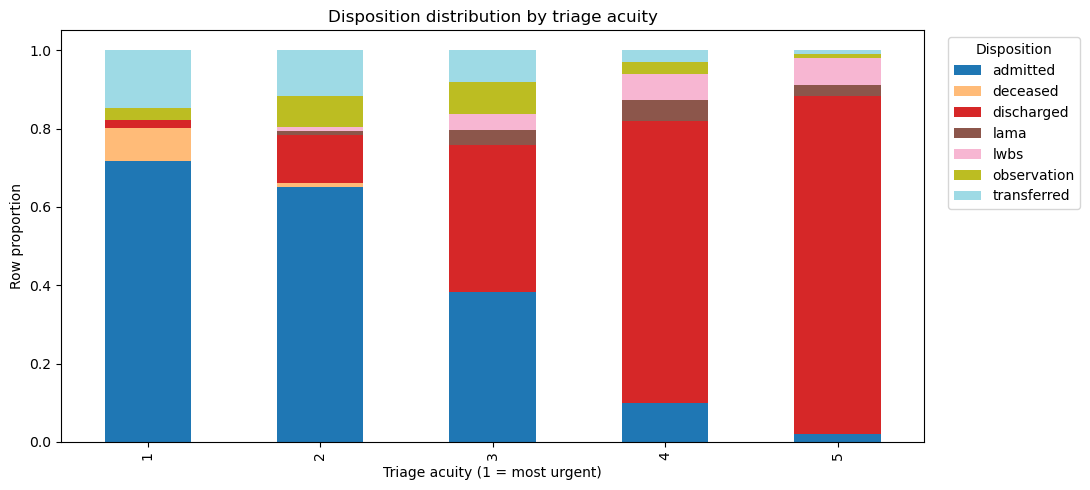

Triage acuity vs ED length of stay


,count,median,mean,q25,q75,p90
triage_acuity,,,,,,
1,3222,7.960,7.960,5.910,9.950,11.730
2,13439,6.020,6.040,4.350,7.740,9.220
3,28921,3.990,3.980,2.960,4.990,5.900
4,23020,2.000,2.010,1.320,2.660,3.270
5,11398,1.000,1.010,0.670,1.340,1.650


/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/ipykernel_2771/3556294109.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(plot_df[TARGET_COL].dropna().unique()), showfliers=False)


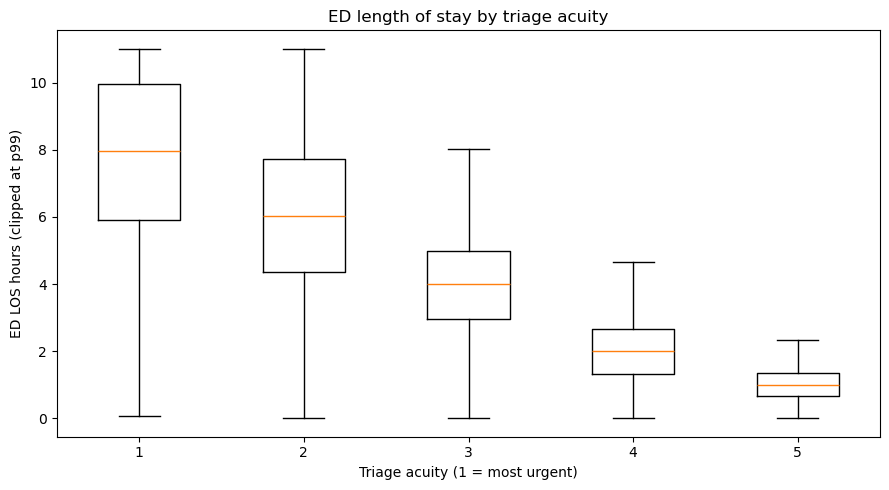

,low_acuity_4_5_cases,low_acuity_with_severe_downstream_proxy,rate_among_low_acuity
0,34418,3283,0.095


,patient_id,triage_acuity,disposition,ed_los_hours,chief_complaint_raw,news2_score,spo2,gcs_total
13,TG-RJC7LSWWP,4,admitted,2.250,ear pain with fever,1,100.000,15
37,TG-G80L23F7L,4,transferred,0.770,"minor skin rash, constant",0,96.700,15
40,TG-RELFNCVUM,5,transferred,1.460,inhaler technique question in known patient,0,97.800,15
61,TG-GZOYMVPT3,4,admitted,2.660,non-bloody diarrhoea with fever,2,97.000,15
69,TG-O5JS7HVHV,4,admitted,3.080,vaginal bleeding light with vomiting,1,96.300,15
164,TG-NZOK25VOB,4,transferred,2.960,diabetes management question with vomiting,1,100.000,15
221,TG-U2N6GJF1R,4,admitted,2.060,"mild low back pain, constant",1,99.200,15
239,TG-AUBGA0TZD,4,admitted,3.560,"uncomplicated UTI symptoms, onset today",0,95.500,15
241,TG-4PO7JHYN4,4,transferred,2.270,mild contact dermatitis，worsening over hours,1,99.500,15
243,TG-SC1ZQYQG3,4,admitted,1.390,"hand paraesthesia, onset today",2,100.000,15


Interpretation: these outcome variables are post-triage retrospective signals only. They are excluded from preprocessing feature matrices and cannot prove true clinical under-triage without chart review.


In [43]:
# Retrospective analysis only: outcome columns are not allowed in model features.
if {TARGET_COL, "disposition"}.issubset(train_eda.columns):
    disposition_counts = pd.crosstab(train_eda[TARGET_COL], train_eda["disposition"], margins=True)
    disposition_pct = pd.crosstab(train_eda[TARGET_COL], train_eda["disposition"], normalize="index").round(3)
    print("Triage acuity vs disposition counts")
    display(disposition_counts)
    print("Triage acuity vs disposition row percentages")
    display(disposition_pct)

    ax = disposition_pct.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20")
    ax.set_title("Disposition distribution by triage acuity")
    ax.set_xlabel("Triage acuity (1 = most urgent)")
    ax.set_ylabel("Row proportion")
    ax.legend(title="Disposition", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

if {TARGET_COL, "ed_los_hours"}.issubset(train_eda.columns):
    los_summary = train_eda.groupby(TARGET_COL)["ed_los_hours"].agg(
        count="count",
        median="median",
        mean="mean",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    ).round(2)
    print("Triage acuity vs ED length of stay")
    display(los_summary)

    clipped_los = train_eda["ed_los_hours"].clip(upper=train_eda["ed_los_hours"].quantile(0.99))
    plot_df = train_eda.assign(ed_los_hours_clipped=clipped_los)
    data = [plot_df.loc[plot_df[TARGET_COL].eq(level), "ed_los_hours_clipped"].dropna() for level in sorted(plot_df[TARGET_COL].dropna().unique())]
    plt.figure(figsize=(9, 5))
    plt.boxplot(data, labels=sorted(plot_df[TARGET_COL].dropna().unique()), showfliers=False)
    plt.title("ED length of stay by triage acuity")
    plt.xlabel("Triage acuity (1 = most urgent)")
    plt.ylabel("ED LOS hours (clipped at p99)")
    plt.tight_layout()
    plt.show()

severe_disposition_proxy = pd.Series(False, index=train_eda.index)
if "disposition" in train_eda.columns:
    disposition_text = train_eda["disposition"].astype(str).str.lower().str.replace(" ", "_", regex=False)
    severe_disposition_proxy = disposition_text.str.contains("icu|critical|death|expire|operating|transfer|admit", regex=True, na=False)

long_los_proxy = pd.Series(False, index=train_eda.index)
if "ed_los_hours" in train_eda.columns:
    long_los_proxy = train_eda["ed_los_hours"].ge(train_eda["ed_los_hours"].quantile(0.95))

low_acuity_mask = train_eda[TARGET_COL].isin([4, 5])
severe_downstream_proxy = severe_disposition_proxy | long_los_proxy
low_acuity_severe_proxy = low_acuity_mask & severe_downstream_proxy

low_acuity_proxy_summary = pd.DataFrame({
    "low_acuity_4_5_cases": [int(low_acuity_mask.sum())],
    "low_acuity_with_severe_downstream_proxy": [int(low_acuity_severe_proxy.sum())],
    "rate_among_low_acuity": [low_acuity_severe_proxy.sum() / max(low_acuity_mask.sum(), 1)],
})
display(low_acuity_proxy_summary)

case_cols = [col for col in [ID_COL, TARGET_COL, "disposition", "ed_los_hours", "chief_complaint_raw", "news2_score", "spo2", "gcs_total"] if col in train_eda.columns]
display(train_eda.loc[low_acuity_severe_proxy, case_cols].head(20))

print("Interpretation: these outcome variables are post-triage retrospective signals only. They are excluded from preprocessing feature matrices and cannot prove true clinical under-triage without chart review.")

## Preprocessing functions

The functions below define the official preprocessing handoff. They copy input data before modifying it, avoid row deletion, apply the same logic to train and test, and defensively skip source-dependent features when a source column is unavailable.

In [44]:
def _clean_complaint_text(value):
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = re.sub(r"[^a-z0-9\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_invalid_values(df):
    """Convert clinically impossible values to NaN and add explicit invalid indicators."""
    df = df.copy()

    invalid_bounds = {
        "pain_score": (0, 10),
        "gcs_total": (3, 15),
        "spo2": (0, 100),
        "temperature_c": (30, 45),
        "heart_rate": (20, 250),
        "respiratory_rate": (3, 80),
        "systolic_bp": (40, 300),
        "diastolic_bp": (20, 200),
    }

    for col, (lower, upper) in invalid_bounds.items():
        invalid_col = f"{col}_invalid"
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce")
            invalid_mask = values.notna() & ((values < lower) | (values > upper))
            df[invalid_col] = invalid_mask.astype(int)
            df[col] = values.mask(invalid_mask, np.nan)
        else:
            df[invalid_col] = 0

    if {"systolic_bp", "diastolic_bp"}.issubset(df.columns):
        df["bp_inconsistent"] = (
            df["systolic_bp"].notna()
            & df["diastolic_bp"].notna()
            & (df["systolic_bp"] < df["diastolic_bp"])
        ).astype(int)
    else:
        df["bp_inconsistent"] = 0

    return df


def add_missing_indicators(df):
    """Create missingness indicators for clinical variables and a core vital missing count."""
    df = df.copy()

    for col in KEY_CLINICAL_COLS:
        if col in df.columns:
            df[f"{col}_missing"] = df[col].isna().astype(int)

    vital_indicator_cols = [f"{col}_missing" for col in CORE_VITAL_COLS if f"{col}_missing" in df.columns]
    df["missing_vital_count"] = df[vital_indicator_cols].sum(axis=1) if vital_indicator_cols else 0

    return df


def add_clinical_features(df):
    """Add derived vital features and interpretable clinical risk flags."""
    df = df.copy()

    if "pain_score" in df.columns:
        df["pain_score_clean"] = df["pain_score"]

    if {"systolic_bp", "diastolic_bp"}.issubset(df.columns):
        df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]
        df.loc[df["bp_inconsistent"].eq(1), "pulse_pressure"] = np.nan
        df["mean_arterial_pressure"] = df["diastolic_bp"] + df["pulse_pressure"] / 3
        df.loc[df["bp_inconsistent"].eq(1), "mean_arterial_pressure"] = np.nan

    if {"heart_rate", "systolic_bp"}.issubset(df.columns):
        systolic_nonzero = df["systolic_bp"].replace(0, np.nan)
        df["shock_index"] = df["heart_rate"] / systolic_nonzero

    flag_rules = {
        "high_news2": ("news2_score", lambda s: s >= 5),
        "low_gcs": ("gcs_total", lambda s: s < 15),
        "very_low_gcs": ("gcs_total", lambda s: s <= 8),
        "low_spo2": ("spo2", lambda s: s < 94),
        "very_low_spo2": ("spo2", lambda s: s < 90),
        "tachypnea": ("respiratory_rate", lambda s: s >= 22),
        "fever": ("temperature_c", lambda s: s >= 38),
        "severe_pain": ("pain_score_clean", lambda s: s >= 8),
        "hypotension": ("systolic_bp", lambda s: s < 90),
    }

    for flag, (source_col, rule) in flag_rules.items():
        if source_col in df.columns:
            df[flag] = rule(df[source_col]).fillna(False).astype(int)

    if "mental_status_triage" in df.columns:
        altered_values = {"confused", "drowsy", "unresponsive", "agitated", "altered"}
        df["altered_mental_status_flag"] = df["mental_status_triage"].astype(str).str.lower().isin(altered_values).astype(int)
    else:
        df["altered_mental_status_flag"] = 0

    return df


def add_history_features(df):
    """Fill binary history flags and add summary history features."""
    df = df.copy()

    hx_cols = [col for col in df.columns if col.startswith("hx_")]
    if hx_cols:
        df[hx_cols] = df[hx_cols].fillna(0)
        df["comorbidity_count"] = df[hx_cols].sum(axis=1)
    else:
        df["comorbidity_count"] = 0

    high_risk_history_cols = [
        "hx_copd",
        "hx_heart_failure",
        "hx_ckd",
        "hx_immunosuppressed",
        "hx_coagulopathy",
        "hx_pregnant",
        "hx_coronary_artery_disease",
        "hx_stroke_prior",
        "hx_malignancy",
    ]
    available_high_risk_cols = [col for col in high_risk_history_cols if col in df.columns]
    if available_high_risk_cols:
        df["high_risk_history_flag"] = (df[available_high_risk_cols].fillna(0).eq(1).any(axis=1)).astype(int)
    else:
        df["high_risk_history_flag"] = 0

    return df


def clean_text_features(df):
    """Clean complaint text and add simple red-flag keyword indicators."""
    df = df.copy()

    if "chief_complaint_raw" not in df.columns:
        df["chief_complaint_raw"] = np.nan

    raw = df["chief_complaint_raw"]
    df["chief_complaint_missing"] = raw.isna().astype(int)
    df["chief_complaint_raw_clean"] = raw.map(_clean_complaint_text)
    df["chief_complaint_char_len"] = raw.fillna("").astype(str).str.len()
    df["chief_complaint_word_count"] = df["chief_complaint_raw_clean"].str.split().str.len()

    redflag_patterns = {
        "complaint_redflag_chest_pain": r"\b(chest pain|chest pressure|chest tightness)\b",
        "complaint_redflag_shortness_of_breath": r"\b(shortness of breath|sob|dyspnea|breathless)\b",
        "complaint_redflag_syncope": r"\b(syncope|faint|collapse|passed out)\b",
        "complaint_redflag_stroke_like": r"\b(stroke|facial droop|slurred speech|aphasia|one sided weakness|weakness)\b",
        "complaint_redflag_trauma": r"\b(trauma|fall|fracture|crash|assault|injury)\b",
        "complaint_redflag_bleeding": r"\b(bleeding|hemorrhage|haemorrhage|hematemesis|melena)\b",
        "complaint_redflag_pregnancy": r"\b(pregnan|labor|vaginal bleeding|ectopic)\b",
        "complaint_redflag_severe_headache": r"\b(thunderclap|worst headache|severe headache)\b",
    }
    for flag, pattern in redflag_patterns.items():
        df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)

    return df


def prepare_features(main_df, complaints_df, history_df, is_train=True):
    """Merge raw inputs and apply identical non-model preprocessing to train/test rows."""
    df = main_df.copy()

    df = df.merge(complaints_df.copy(), on=ID_COL, how="left", suffixes=("", "_complaints"))

    complaint_system_suffix = "chief_complaint_system_complaints"
    if complaint_system_suffix in df.columns:
        if "chief_complaint_system" in df.columns:
            both_present = df["chief_complaint_system"].notna() & df[complaint_system_suffix].notna()
            inconsistent = both_present & (df["chief_complaint_system"] != df[complaint_system_suffix])
            if inconsistent.any():
                print(
                    f"Warning: {int(inconsistent.sum())} rows have inconsistent chief_complaint_system values; "
                    "using main table first, then complaint table."
                )
            df["chief_complaint_system"] = df["chief_complaint_system"].combine_first(df[complaint_system_suffix])
            df = df.drop(columns=[complaint_system_suffix])
        else:
            df = df.rename(columns={complaint_system_suffix: "chief_complaint_system"})

    df = df.merge(history_df.copy(), on=ID_COL, how="left")

    df = clean_invalid_values(df)
    df = add_missing_indicators(df)
    df = add_clinical_features(df)
    df = add_history_features(df)
    df = clean_text_features(df)

    leakage_to_drop = [col for col in LEAKAGE_COLS if col in df.columns]
    if leakage_to_drop:
        df = df.drop(columns=leakage_to_drop)

    if not is_train and TARGET_COL in df.columns:
        df = df.drop(columns=[TARGET_COL])

    return df


## Apply preprocessing to train/test

In [45]:
train_processed = prepare_features(train, chief_complaints, patient_history, is_train=True)
test_processed = prepare_features(test, chief_complaints, patient_history, is_train=False)

print(f"train_processed shape: {train_processed.shape}")
print(f"test_processed shape: {test_processed.shape}")

/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/ipykernel_2771/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/ipykernel_2771/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/ipykernel_2771/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/

train_processed shape: (80000, 108)
test_processed shape: (20000, 107)


/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/ipykernel_2771/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/ipykernel_2771/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/ipykernel_2771/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/l7/gl2dl84j4jvg_dsp6_w5_lrw0000gn/T/

## Validate processed outputs

In [46]:
assert train_processed[ID_COL].is_unique, "train_processed contains duplicate patient_id values"
assert test_processed[ID_COL].is_unique, "test_processed contains duplicate patient_id values"
assert TARGET_COL in train_processed.columns, "train_processed must contain triage_acuity"
assert TARGET_COL not in test_processed.columns, "test_processed must not contain triage_acuity"
assert ID_COL in train_processed.columns and ID_COL in test_processed.columns, "patient_id must be preserved"
assert not set(LEAKAGE_COLS).intersection(train_processed.columns), "Leakage columns found in train_processed"
assert not set(LEAKAGE_COLS).intersection(test_processed.columns), "Leakage columns found in test_processed"

train_feature_cols = set(train_processed.columns) - {TARGET_COL}
test_feature_cols = set(test_processed.columns)
train_not_test = sorted(train_feature_cols - test_feature_cols)
test_not_train = sorted(test_feature_cols - train_feature_cols)

assert not train_not_test, f"Feature columns in train but not test: {train_not_test}"
assert not test_not_train, f"Feature columns in test but not train: {test_not_train}"

shape_summary = pd.DataFrame(
    {
        "dataset": ["train_raw", "test_raw", "train_processed", "test_processed"],
        "rows": [len(train), len(test), len(train_processed), len(test_processed)],
        "columns": [train.shape[1], test.shape[1], train_processed.shape[1], test_processed.shape[1]],
    }
)
display(shape_summary)

print("Columns in train_processed but not test_processed, excluding triage_acuity:", train_not_test)
print("Columns in test_processed but not train_processed:", test_not_train)

,dataset,rows,columns
0,train_raw,80000,40
1,test_raw,20000,37
2,train_processed,80000,108
3,test_processed,20000,107


Columns in train_processed but not test_processed, excluding triage_acuity: []
Columns in test_processed but not train_processed: []


## Train/test drift summary

These tables compare raw distributions and processed features between train and test. They are EDA checks only and are not model training.

In [47]:
missing_drift_cols = [col for col in KEY_CLINICAL_COLS if col in train_processed.columns and col in test_processed.columns]
missing_drift_summary = pd.DataFrame(
    {
        "column": missing_drift_cols,
        "train_missing_rate": [train_processed[col].isna().mean() for col in missing_drift_cols],
        "test_missing_rate": [test_processed[col].isna().mean() for col in missing_drift_cols],
    }
)
missing_drift_summary["absolute_difference"] = (
    missing_drift_summary["test_missing_rate"] - missing_drift_summary["train_missing_rate"]
).abs()
display(missing_drift_summary.sort_values("absolute_difference", ascending=False))

,column,train_missing_rate,test_missing_rate,absolute_difference
7,pain_score,0.139,0.146,0.006
0,systolic_bp,0.052,0.048,0.004
1,diastolic_bp,0.052,0.048,0.004
4,temperature_c,0.007,0.005,0.002
3,respiratory_rate,0.038,0.038,0.001
2,heart_rate,0.000,0.000,0.000
5,spo2,0.000,0.000,0.000
6,gcs_total,0.000,0.000,0.000
8,news2_score,0.000,0.000,0.000


In [48]:
def categorical_drift_summary(train_df, test_df, columns):
    rows = []
    for col in columns:
        if col not in train_df.columns or col not in test_df.columns:
            rows.append(
                {
                    "column": col,
                    "train_unique_levels": np.nan,
                    "test_unique_levels": np.nan,
                    "unseen_test_level_count": np.nan,
                    "unseen_test_levels_sample": "column missing",
                }
            )
            continue

        train_levels = set(train_df[col].fillna("__MISSING__").astype(str))
        test_levels = set(test_df[col].fillna("__MISSING__").astype(str))
        unseen = sorted(test_levels - train_levels)
        rows.append(
            {
                "column": col,
                "train_unique_levels": len(train_levels),
                "test_unique_levels": len(test_levels),
                "unseen_test_level_count": len(unseen),
                "unseen_test_levels_sample": ", ".join(unseen[:20]),
            }
        )
    return pd.DataFrame(rows)

categorical_drift = categorical_drift_summary(train_processed, test_processed, CATEGORICAL_DRIFT_COLS)
display(categorical_drift)

,column,train_unique_levels,test_unique_levels,unseen_test_level_count,unseen_test_levels_sample
0,site_id,5,5,0,
1,triage_nurse_id,50,50,0,
2,arrival_mode,6,6,0,
3,language,8,8,0,
4,insurance_type,5,5,0,
5,transport_origin,7,7,0,
6,pain_location,9,9,0,
7,mental_status_triage,5,5,0,
8,chief_complaint_system,14,14,0,


In [49]:
def numeric_drift_summary(train_df, test_df, columns):
    rows = []
    for col in columns:
        if col not in train_df.columns or col not in test_df.columns:
            rows.append({"column": col, "status": "column missing"})
            continue
        rows.append(
            {
                "column": col,
                "status": "ok",
                "train_mean": train_df[col].mean(),
                "test_mean": test_df[col].mean(),
                "train_median": train_df[col].median(),
                "test_median": test_df[col].median(),
                "train_std": train_df[col].std(),
                "test_std": test_df[col].std(),
                "train_p05": train_df[col].quantile(0.05),
                "test_p05": test_df[col].quantile(0.05),
                "train_p95": train_df[col].quantile(0.95),
                "test_p95": test_df[col].quantile(0.95),
            }
        )
    return pd.DataFrame(rows)

numeric_drift = numeric_drift_summary(train_processed, test_processed, NUMERIC_DRIFT_COLS)
display(numeric_drift)

,column,status,train_mean,test_mean,train_median,test_median,train_std,test_std,train_p05,test_p05,train_p95,test_p95
0,age,ok,48.544,48.295,48.000,48.000,24.188,24.078,10.000,10.000,89.000,89.000
1,systolic_bp,ok,121.613,121.590,123.100,123.200,24.222,24.418,79.000,78.700,158.900,159.415
2,diastolic_bp,ok,74.452,74.578,75.300,75.600,14.286,14.319,49.100,49.000,96.300,96.400
3,heart_rate,ok,91.859,91.866,89.600,89.700,19.489,19.486,64.100,63.900,127.400,127.400
4,respiratory_rate,ok,18.334,18.353,17.300,17.300,4.647,4.616,12.700,12.800,27.900,27.900
5,temperature_c,ok,37.631,37.630,37.500,37.500,0.857,0.853,36.400,36.400,39.200,39.200
6,spo2,ok,95.794,95.795,97.000,97.000,4.307,4.279,87.000,87.100,100.000,100.000
7,gcs_total,ok,14.152,14.170,15.000,15.000,2.146,2.106,9.000,9.000,15.000,15.000
8,pain_score_clean,ok,5.398,5.417,5.000,5.000,2.722,2.714,1.000,1.000,10.000,10.000
9,news2_score,ok,3.427,3.434,2.000,2.000,4.259,4.251,0.000,0.000,13.000,13.000


## Save processed files

In [50]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_processed_path = PROCESSED_DIR / "train_processed.csv"
test_processed_path = PROCESSED_DIR / "test_processed.csv"
feature_report_path = PROCESSED_DIR / "feature_report.csv"
legacy_feature_report_path = PROCESSED_DIR / "preprocessing_feature_report.csv"
preprocessing_report_path = PROCESSED_DIR / "preprocessing_report.csv"
eda_summary_path = PROCESSED_DIR / "eda_summary.md"

train_processed.to_csv(train_processed_path, index=False)
test_processed.to_csv(test_processed_path, index=False)

report_columns = sorted(set(train_processed.columns).union(test_processed.columns).union(LEAKAGE_COLS))
feature_report_rows = []
for col in report_columns:
    if col == TARGET_COL:
        role = "target"
        source = "target"
    elif col == ID_COL:
        role = "row_alignment_id_drop_before_modeling"
        source = "identifier"
    elif col in LEAKAGE_COLS:
        role = "excluded_post_triage_outcome"
        source = "outcome"
    elif col.endswith("_invalid") or col == "bp_inconsistent":
        role = "feature"
        source = "invalid_indicator"
    elif col.startswith("complaint_redflag_") or col.startswith("chief_complaint_"):
        role = "feature"
        source = "complaint"
    elif col.startswith("hx_") or col in ["comorbidity_count", "high_risk_history_flag"]:
        role = "feature"
        source = "history"
    elif col.endswith("_missing") or col == "missing_vital_count":
        role = "feature"
        source = "missing_indicator"
    elif col in CORE_VITAL_COLS + ["gcs_total", "pain_score", "news2_score", "shock_index", "pulse_pressure", "mean_arterial_pressure"]:
        role = "feature"
        source = "clinical"
    else:
        role = "feature"
        source = "structured"

    feature_report_rows.append(
        {
            "column_name": col,
            "dtype": str(train_processed[col].dtype) if col in train_processed.columns else str(test_processed[col].dtype) if col in test_processed.columns else "not_in_processed_outputs",
            "missing_rate_train_processed": train_processed[col].isna().mean() if col in train_processed.columns else np.nan,
            "missing_rate_test_processed": test_processed[col].isna().mean() if col in test_processed.columns else np.nan,
            "role": role,
            "source": source,
        }
    )

feature_report = pd.DataFrame(feature_report_rows)
feature_report.to_csv(feature_report_path, index=False)
feature_report.to_csv(legacy_feature_report_path, index=False)

invalid_indicator_cols = [
    "pain_score_invalid",
    "gcs_total_invalid",
    "spo2_invalid",
    "temperature_c_invalid",
    "heart_rate_invalid",
    "respiratory_rate_invalid",
    "systolic_bp_invalid",
    "diastolic_bp_invalid",
    "bp_inconsistent",
]
redflag_cols = [col for col in train_processed.columns if col.startswith("complaint_redflag_")]
train_feature_cols = set(train_processed.columns) - {TARGET_COL}
test_feature_cols = set(test_processed.columns)

preprocessing_report_rows = [
    {"metric": "train_processed_rows", "value": len(train_processed)},
    {"metric": "train_processed_columns", "value": train_processed.shape[1]},
    {"metric": "test_processed_rows", "value": len(test_processed)},
    {"metric": "test_processed_columns", "value": test_processed.shape[1]},
    {"metric": "feature_columns_equal_excluding_target", "value": train_feature_cols == test_feature_cols},
    {"metric": "target_column", "value": TARGET_COL},
    {"metric": "patient_id_preserved_for_alignment", "value": ID_COL in train_processed.columns and ID_COL in test_processed.columns},
    {"metric": "leakage_columns_excluded", "value": not set(LEAKAGE_COLS).intersection(train_processed.columns.union(test_processed.columns))},
    {"metric": "redflag_feature_count", "value": len(redflag_cols)},
]
for col in invalid_indicator_cols:
    preprocessing_report_rows.append({"metric": f"train_sum__{col}", "value": int(train_processed[col].sum()) if col in train_processed.columns else np.nan})
    preprocessing_report_rows.append({"metric": f"test_sum__{col}", "value": int(test_processed[col].sum()) if col in test_processed.columns else np.nan})

preprocessing_report = pd.DataFrame(preprocessing_report_rows)
preprocessing_report.to_csv(preprocessing_report_path, index=False)

high_acuity_rate = train_processed[TARGET_COL].isin([1, 2]).mean()
eda_summary = f"""# EDA and Preprocessing Summary

Generated outputs:
- `{train_processed_path}`
- `{test_processed_path}`
- `{feature_report_path}`
- `{preprocessing_report_path}`

Target:
- `{TARGET_COL}` is retained only in train.
- High acuity is acuity 1 or 2; observed train high-acuity rate is {high_acuity_rate:.2%}.

Leakage and row alignment:
- `patient_id` is preserved in processed outputs only for row alignment/submission bookkeeping.
- Modeling code must drop `patient_id` from the feature matrix.
- `disposition` and `ed_los_hours` are post-triage outcome variables and are excluded from processed model features.

Preprocessing additions:
- Invalid clinical values are set to missing and paired with explicit invalid indicators.
- Blood pressure inconsistency is flagged with `bp_inconsistent`.
- Chief complaint red-flag keyword features are included.
- `altered_mental_status_flag` is included.

Retrospective outcomes:
- Outcome analyses are post-hoc consistency checks only and must not be used for model training.
"""
eda_summary_path.write_text(eda_summary, encoding="utf-8")

display(
    pd.DataFrame(
        {
            "output": ["train_processed", "test_processed", "feature_report", "preprocessing_report", "eda_summary"],
            "path": [str(train_processed_path), str(test_processed_path), str(feature_report_path), str(preprocessing_report_path), str(eda_summary_path)],
            "rows": [len(train_processed), len(test_processed), len(feature_report), len(preprocessing_report), np.nan],
            "columns": [train_processed.shape[1], test_processed.shape[1], feature_report.shape[1], preprocessing_report.shape[1], np.nan],
        }
    )
)


,output,path,rows,columns
0,train_processed,data/processed/train_processed.csv,80000.000,108.000
1,test_processed,data/processed/test_processed.csv,20000.000,107.000
2,feature_report,data/processed/feature_report.csv,110.000,6.000
3,preprocessing_report,data/processed/preprocessing_report.csv,27.000,2.000
4,eda_summary,data/processed/eda_summary.md,NaN,NaN


## Final modeling handoff

- Use `data/processed/train_processed.csv` and `data/processed/test_processed.csv` as the handoff files for modeling.
- `triage_acuity` is the target and is retained only in `train_processed.csv`.
- `patient_id` is intentionally preserved in processed outputs only for row alignment, validation bookkeeping, and submission alignment.
- Modeling code must drop `patient_id` from the feature matrix before training or inference.
- Do not use `disposition` or `ed_los_hours` as model features; both are post-triage outcome variables and are removed from processed outputs.
- Consider excluding `triage_nurse_id` in a clinically constrained model because it may encode operational practice patterns rather than patient clinical state.
- Recommended model comparisons: majority baseline, structured model, structured + history model, text-only model, fused model, and model without `triage_nurse_id`.
- Recommended metrics: accuracy, macro F1, weighted F1, MAE, quadratic weighted kappa, confusion matrix, high-acuity recall, and severe model under-triage error.
- This notebook intentionally does not train final classifiers or generate Kaggle submissions.
